# AMALi
During all campaigns, except HAMAG, the Airborne Mobile Aerosol Lidar for Arctic research (AMALi; *Stachlewska et al., 2014*) has been operated onboard the Polar 5. From the backscatter signal, a cloud mask and cloud top heights were derived. The dataset is available on the PANGAEA database for [ACLOUD](https://doi.pangaea.de/10.1594/PANGAEA.932454), [AFLUX](https://doi.pangaea.de/10.1594/PANGAEA.932455), [MOSAiC-ACA](https://doi.pangaea.de/10.1594/PANGAEA.932456), and [HALO-AC3](https://doi.pangaea.de/10.1594/PANGAEA.964985) and for COMPEX-EC and COMPEX on request.

If you have questions or if you would like to use the data for a publication, please don't hesitate to get in contact with the dataset authors as stated in the dataset attributes `contact` or `author`.

In [28]:
import os

# local caching
try:
    from dotenv import load_dotenv

    load_dotenv()

    local_storage = os.environ['INTAKE_CACHE']
except ImportError:
    local_storage = '/tmp/'

kwds = {'simplecache': dict(
    cache_storage=local_storage, 
    same_names=True
)}

# needed for data stored in AC3 cloud
try:
    ac3cloud_username = os.environ['AC3_USER']
    ac3cloud_password = os.environ['AC3_PASSWORD']
    credentials = dict(user=ac3cloud_username, password=ac3cloud_password)
except ImportError:
    credentials = {}
    print("Only publicaly available datasets from ACLOUD, AFLUX, MOSAiC-ACA, and HALO-AC3 are accessible!")


First, we import the airborne catalogues to get the meta information of the datasets. To do so the ac3airborne package has to be installed. More information on how to do that and about the catalog can be found [here](https://github.com/igmk/ac3airborne-intake#ac3airborne-intake-catalogue).

In [13]:
import ac3airborne

In [30]:
cat = ac3airborne.get_intake_catalog()

datasets = []
for campaign in ['ACLOUD', 'AFLUX', 'MOSAiC-ACA','HALO-AC3','COMPEX-EC','COMPEX']:
    datasets.extend(list(cat[campaign]['P5']['AMALi']))
print(datasets)

['ACLOUD_P5_RF04', 'ACLOUD_P5_RF05', 'ACLOUD_P5_RF06', 'ACLOUD_P5_RF07', 'ACLOUD_P5_RF08', 'ACLOUD_P5_RF10', 'ACLOUD_P5_RF11', 'ACLOUD_P5_RF13', 'ACLOUD_P5_RF14', 'ACLOUD_P5_RF16', 'ACLOUD_P5_RF17', 'ACLOUD_P5_RF18', 'ACLOUD_P5_RF19', 'ACLOUD_P5_RF20', 'ACLOUD_P5_RF21', 'ACLOUD_P5_RF22', 'ACLOUD_P5_RF23', 'ACLOUD_P5_RF25', 'AFLUX_P5_RF03', 'AFLUX_P5_RF04', 'AFLUX_P5_RF05', 'AFLUX_P5_RF06', 'AFLUX_P5_RF07', 'AFLUX_P5_RF08', 'AFLUX_P5_RF09', 'AFLUX_P5_RF10', 'AFLUX_P5_RF11', 'AFLUX_P5_RF12', 'AFLUX_P5_RF13', 'AFLUX_P5_RF14', 'AFLUX_P5_RF15', 'MOSAiC-ACA_P5_RF04', 'MOSAiC-ACA_P5_RF05', 'MOSAiC-ACA_P5_RF06', 'MOSAiC-ACA_P5_RF07', 'MOSAiC-ACA_P5_RF08', 'MOSAiC-ACA_P5_RF09', 'MOSAiC-ACA_P5_RF10', 'MOSAiC-ACA_P5_RF11', 'HALO-AC3_P5_RF01', 'HALO-AC3_P5_RF03', 'HALO-AC3_P5_RF04', 'HALO-AC3_P5_RF05', 'HALO-AC3_P5_RF07', 'HALO-AC3_P5_RF08', 'HALO-AC3_P5_RF09', 'HALO-AC3_P5_RF10', 'HALO-AC3_P5_RF11', 'HALO-AC3_P5_RF12', 'HALO-AC3_P5_RF13', 'COMPEX-EC_P5_RF01', 'COMPEX-EC_P5_RF02', 'COMPEX-EC_P5_RF

In [15]:
flight_id = 'COMPEX_P5_RF08'
campaign,platform,rf = flight_id.split('_')

We will load the level 1 dataset for a specific flight and see what can be found in there. `ds_amali` shows all relevant information on the dataset, such as author, contact, or citation information.

In [31]:
ds_amali = cat[campaign][platform]['AMALi'][flight_id](storage_options=kwds,**credentials).to_dask()
ds_amali

/net/sever/mech/miniconda3/envs/howtoac3/lib/python3.11/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 591MB
Dimensions:              (i_channel: 6, time: 8928, range: 600, height: 761)
Coordinates:
  * i_channel            (i_channel) int64 48B 0 1 2 3 4 5
  * time                 (time) datetime64[ns] 71kB 2026-03-27T13:23:55 ... 2...
  * height               (height) float64 6kB -300.0 -292.5 ... 5.4e+03
Dimensions without coordinates: range
Data variables: (12/15)
    snr                  (i_channel, time, range) float64 257MB ...
    channel_wvl          (i_channel) float64 48B ...
    channel_pol          (i_channel) <U1 24B ...
    channel_analog       (i_channel) object 48B ...
    surf_alt             (time) float64 71kB ...
    alt                  (time) float64 71kB ...
    ...                   ...
    pitch                (time) float64 71kB ...
    heading              (time) float64 71kB ...
    log_beta             (i_channel, time, height) float64 326MB ...
    lowest_laser_height  (time) float64 71kB ...
    laser_range_flag     (time) int8 9kB ...
    quality_flag         (time, height) uint8 7MB ...
Attributes: (12/13)
    institution:  Institute of Geophysics and Meteorology (IGM), University o...
    source:       airborne observation
    author:       Jan Schween (jschween@uni-koeln.de); Mario Mech(mario.mech@...
    convention:   CF-1.8
    featureType:  trajectory
    mission:      COMPEX
    ...           ...
    flight_id:    COMPEX_P5_RF07
    title:        logarithmic volume attenuated backscatter coefficient based...
    instrument:   AMALi (Airborne Mobile Aerosol Lidar for Arctic research)
    history:      corrected for background, range and incomplete overlap and ...
    contact:      n.risse@uni-koeln.de
    created:      2026-03-29T10:41:32

And the same for `ds_cloud_top_height` and `ds_cloud_mask`, the level 2 datasets with derived cloud top heights and the clodu mask based on AMALi.

In [32]:
ds_cloud_top_height = cat[campaign]['P5']['AMALi_CTH'][flight_id](storage_options=kwds,**credentials).to_dask()
ds_cloud_top_height

/net/sever/mech/miniconda3/envs/howtoac3/lib/python3.11/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 44MB
Dimensions:              (time: 8928, boundary: 2, range: 600, cloud_layer: 10)
Coordinates:
  * time                 (time) datetime64[ns] 71kB 2026-03-27T13:23:55 ... 2...
  * boundary             (boundary) <U5 40B 'lower' 'upper'
  * cloud_layer          (cloud_layer) int64 80B 1 2 3 4 5 6 7 8 9 10
Dimensions without coordinates: range
Data variables:
    snr                  (time, range) float64 43MB ...
    surf_alt             (time) float64 71kB ...
    alt                  (time) float64 71kB ...
    lat                  (time) float64 71kB ...
    lon                  (time) float64 71kB ...
    roll                 (time) float64 71kB ...
    pitch                (time) float64 71kB ...
    heading              (time) float64 71kB ...
    lowest_laser_height  (time) float64 71kB ...
    laser_range_flag     (time) int8 9kB ...
    valid_height         (time, boundary) float64 143kB ...
    cth                  (time, cloud_layer) float64 714kB ...
Attributes: (12/14)
    institution:  Institute of Geophysics and Meteorology (IGM), University o...
    source:       airborne observation
    author:       Nils Risse (n.risse@uni-koeln.de)
    convention:   CF-1.8
    featureType:  trajectory
    mission:      COMPEX
    ...           ...
    title:        cloud top height derived from AMALi observations onboard Po...
    instrument:   AMALi (Airborne Mobile Aerosol Lidar for Arctic research)
    history:      derived from l1 product
    contact:      n.risse@uni-koeln.de
    created:      2026-03-29T12:27:13
    project:      Arctic Amplification (AC3)

In [33]:
ds_cloud_mask = cat[campaign]['P5']['AMALi_CM'][flight_id](storage_options=kwds,**credentials).to_dask()
ds_cloud_mask

/net/sever/mech/miniconda3/envs/howtoac3/lib/python3.11/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 44MB
Dimensions:              (time: 8928, boundary: 2, range: 600)
Coordinates:
  * time                 (time) datetime64[ns] 71kB 2026-03-27T13:23:55 ... 2...
  * boundary             (boundary) <U5 40B 'lower' 'upper'
Dimensions without coordinates: range
Data variables:
    snr                  (time, range) float64 43MB ...
    surf_alt             (time) float64 71kB ...
    alt                  (time) float64 71kB ...
    lat                  (time) float64 71kB ...
    lon                  (time) float64 71kB ...
    roll                 (time) float64 71kB ...
    pitch                (time) float64 71kB ...
    heading              (time) float64 71kB ...
    lowest_laser_height  (time) float64 71kB ...
    laser_range_flag     (time) int8 9kB ...
    valid_height         (time, boundary) float64 143kB ...
    cloud_mask           (time) int64 71kB ...
Attributes: (12/14)
    institution:  Institute of Geophysics and Meteorology (IGM), University o...
    source:       airborne observation
    author:       Nils Risse (n.risse@uni-koeln.de)
    convention:   CF-1.8
    featureType:  trajectory
    mission:      COMPEX
    ...           ...
    title:        cloud mask derived from AMALi observations onboard Polar 5 ...
    instrument:   AMALi (Airborne Mobile Aerosol Lidar for Arctic research)
    history:      derived from l1 product
    contact:      n.risse@uni-koeln.de
    created:      2026-03-29T10:55:05
    project:      Arctic Amplification (AC3)

The datasets include attenuated backscatter signal for each channel (level 1 `ds_amali`: `log_beta`), the cloud top height (level 2 `ds_cloud_top_height`: `cloud_top_height`) and the number of cloud layers (level 2 `ds_cloud_top_height`: `n_cloud_layer`), and a cloud mask derived from the optical depth (level 2 `ds_cloud_mask`: `cloud_mask`). Additionally, the instrument status is provided and positional data of the aircraft (`lat`, `lon`, `alt`).

## Plot the data

First we need a helper function to fill data gaps with nans.

In [19]:
import numpy as np

def fill_time_gap(ds, dt_max=4):
    """
    Fills measurement gaps with nan's. Otherwise, rectangular stripes may occur

    ds:      xarray dataset
    dt_max:  highest tolerated time step
    """

    # creaty copy of the time index
    time_orig = ds.time.values.copy()

    # calculate time stemp in seconds
    dt = (time_orig[1:] - time_orig[:-1]) / np.timedelta64(1, 'ns') * 1e-9
    ix = np.argwhere(dt > dt_max).flatten()

    # create times for additional time steps 1s after (before) start (end) of
    # measurement gap
    time_insert_lower = time_orig[ix] + np.timedelta64(1, 's')
    time_insert_upper = time_orig[ix + 1] - np.timedelta64(1, 's')
    time_insert = np.insert(time_insert_upper, np.arange(len(ix)),
                            time_insert_lower)

    # insert the additional time steps to original time array and reindex the
    # dataset
    time_reindex = np.insert(time_orig, np.repeat(ix, 2) + 1, time_insert)
    ds = ds.reindex({'time': time_reindex})

    return ds

ds_l1 = fill_time_gap(ds_amali, dt_max=1)
ds_cth = fill_time_gap(ds_cloud_top_height, dt_max=1)
ds_cm = fill_time_gap(ds_cloud_mask, dt_max=1)


In [20]:
ds_l1

<xarray.Dataset> Size: 611MB
Dimensions:              (i_channel: 6, time: 8932, height: 761, range: 600)
Coordinates:
  * i_channel            (i_channel) int64 48B 0 1 2 3 4 5
  * time                 (time) datetime64[ns] 71kB 2026-03-27T13:23:55 ... 2...
  * height               (height) float64 6kB -300.0 -292.5 ... 5.4e+03
Dimensions without coordinates: range
Data variables: (12/15)
    snr                  (i_channel, time, range) float64 257MB 0.4023 ... 0....
    channel_wvl          (i_channel) float64 48B ...
    channel_pol          (i_channel) <U1 24B ...
    channel_analog       (i_channel) object 48B ...
    surf_alt             (time) float64 71kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    alt                  (time) float64 71kB 3.081e+03 3.082e+03 ... 2.732e+03
    ...                   ...
    pitch                (time) float64 71kB 5.18 4.87 4.58 ... 0.46 0.51 0.32
    heading              (time) float64 71kB -79.9 -80.16 -80.0 ... 45.37 45.51
    log_beta             (i_channel, time, height) float64 326MB -8.753 ... nan
    lowest_laser_height  (time) float64 71kB -1.334e+03 ... -1.703e+03
    laser_range_flag     (time) float32 36kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    quality_flag         (time, height) float32 27MB 8.0 8.0 8.0 ... 4.0 4.0 4.0
Attributes: (12/13)
    institution:  Institute of Geophysics and Meteorology (IGM), University o...
    source:       airborne observation
    author:       Jan Schween (jschween@uni-koeln.de); Mario Mech(mario.mech@...
    convention:   CF-1.8
    featureType:  trajectory
    mission:      COMPEX
    ...           ...
    flight_id:    COMPEX_P5_RF07
    title:        logarithmic volume attenuated backscatter coefficient based...
    instrument:   AMALi (Airborne Mobile Aerosol Lidar for Arctic research)
    history:      corrected for background, range and incomplete overlap and ...
    contact:      n.risse@uni-koeln.de
    created:      2026-03-29T10:41:32

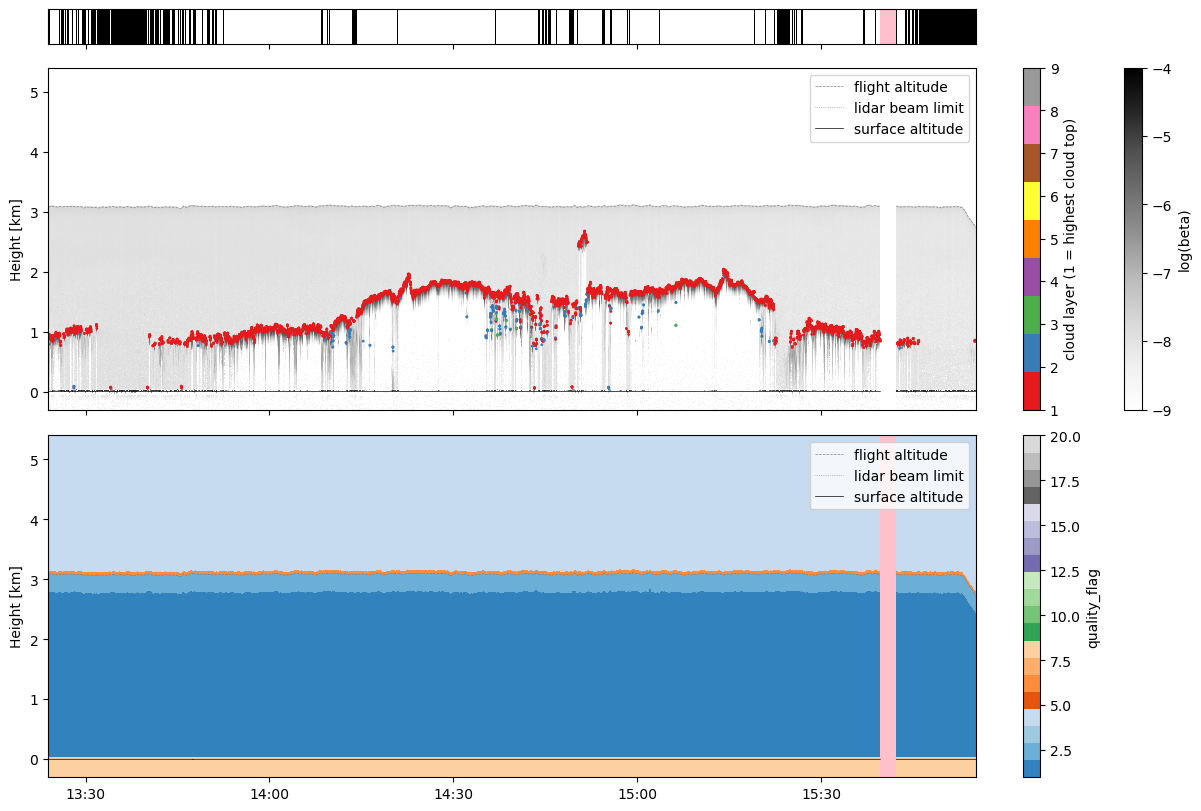

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.dates as mdates

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(12, 8), constrained_layout=True,
    sharex=True, gridspec_kw=dict(height_ratios=[0.1, 1, 1]))

# cloud mask
cmap = cm.Greys_r.copy()
cmap.set_bad('pink')
ax1.pcolormesh(
    ds_cm.time,
    np.array([0, 1]),
    np.array([ds_cm.cloud_mask, ds_cm.cloud_mask]),
    cmap=cmap, vmin=0, vmax=1,
    shading='nearest')
ax1.tick_params(axis='y', labelleft=False, left=False)
ax1.spines[:].set_visible(True)

for ax in (ax2, ax3):

    # flight altitude
    ax.plot(
        ds_l1.time,
        ds_l1.alt*1e-3,
        color='gray', linewidth=0.5, linestyle='--',
        label='flight altitude',
        zorder=1
    )

    # laser beam limit
    ax.plot(
        ds_l1.time,
        ds_l1.lowest_laser_height*1e-3,
        color='gray', linewidth=0.5, linestyle=':',
        label='lidar beam limit',
        zorder=1
    )

    # surface altitude
    ax.plot(
        ds_l1.time,
        ds_l1.surf_alt*1e-3,
        color='k', linewidth=0.5, linestyle='-',
        label='surface altitude',
        zorder=1
    )

# backscatter
im = ax2.pcolormesh(
    ds_l1.time,
    ds_l1.height*1e-3,
    ds_l1.log_beta.sel(i_channel=0).T,
    shading='nearest',
    cmap='Greys',
    vmin=-9, vmax=-4,
    zorder=0
)
fig.colorbar(im, ax=ax2, label='log(beta)')

# cloud top heights for each layer
da_cth = ds_cth.cth.stack({'tl': ['time', 'cloud_layer']})

im = ax2.scatter(
    x=da_cth.time,
    y=da_cth*1e-3,
    c=da_cth.cloud_layer, s=1, vmin=1, vmax=9, cmap='Set1',
    zorder=2)
fig.colorbar(im, ax=ax2, label='cloud layer (1 = highest cloud top)')

# flag values
cmap = cm.tab20c.copy()
cmap.set_bad('pink')
im = ax3.pcolormesh(
    ds_l1.time,
    ds_l1.height*1e-3,
    ds_l1.quality_flag.T,
    shading='nearest',
    vmin=1,
    vmax=20,
    cmap=cmap,
    zorder=0
)
fig.colorbar(im, ax=ax3, label='quality_flag')

for ax in [ax2, ax3]:
    ax.set_ylim(-0.3, 5.4)
    ax.legend(loc='upper right')
    ax.set_ylabel('Height [km]')

ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

## Load Polar 5 flight phase information
Polar 5 flights are divided into segments to easily access start and end times of flight patterns. For more information have a look at the respective [github](https://github.com/igmk/flight-phase-separation) repository.

At first we want to load the flight segments of (AC)³airborne

In [22]:
meta = ac3airborne.get_flight_segments() 

The following command lists all flight segments into the dictionary `segments`

In [23]:
segments = {s.get("segment_id"): {**s, "flight_id": flight["flight_id"]}
            for campaign in meta.values()
            for platform in campaign.values()
            for flight in platform.values()
            for s in flight["segments"]
            }

In this example we want to look at a high-level segment during `COMPEX_P5_RF08`, the EarthCARE collocation of `RF08` during `COMPEX`.

In [39]:
seg = segments[flight_id+"_hl03"]

Using the start and end times of the segment stored in `seg`, we slice the MiRAC data to this flight section.

In [40]:
ds_cloud_top_height_sel = ds_cloud_top_height.sel(time=slice(seg["start"], seg["end"]))
ds_cloud_mask_sel = ds_cloud_mask.sel(time=slice(seg["start"], seg["end"]))

## Plots

The flight section during ACLOUD RF05 is flown at about 3 km altitude in west-east direction during a cold-air outbreak event perpendicular to the wind field. Clearly one can identify the roll-cloud structure in the radar reflectivity and the 89 GHz brightness temperature.

In [41]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.style.use("../../mplstyle/book")

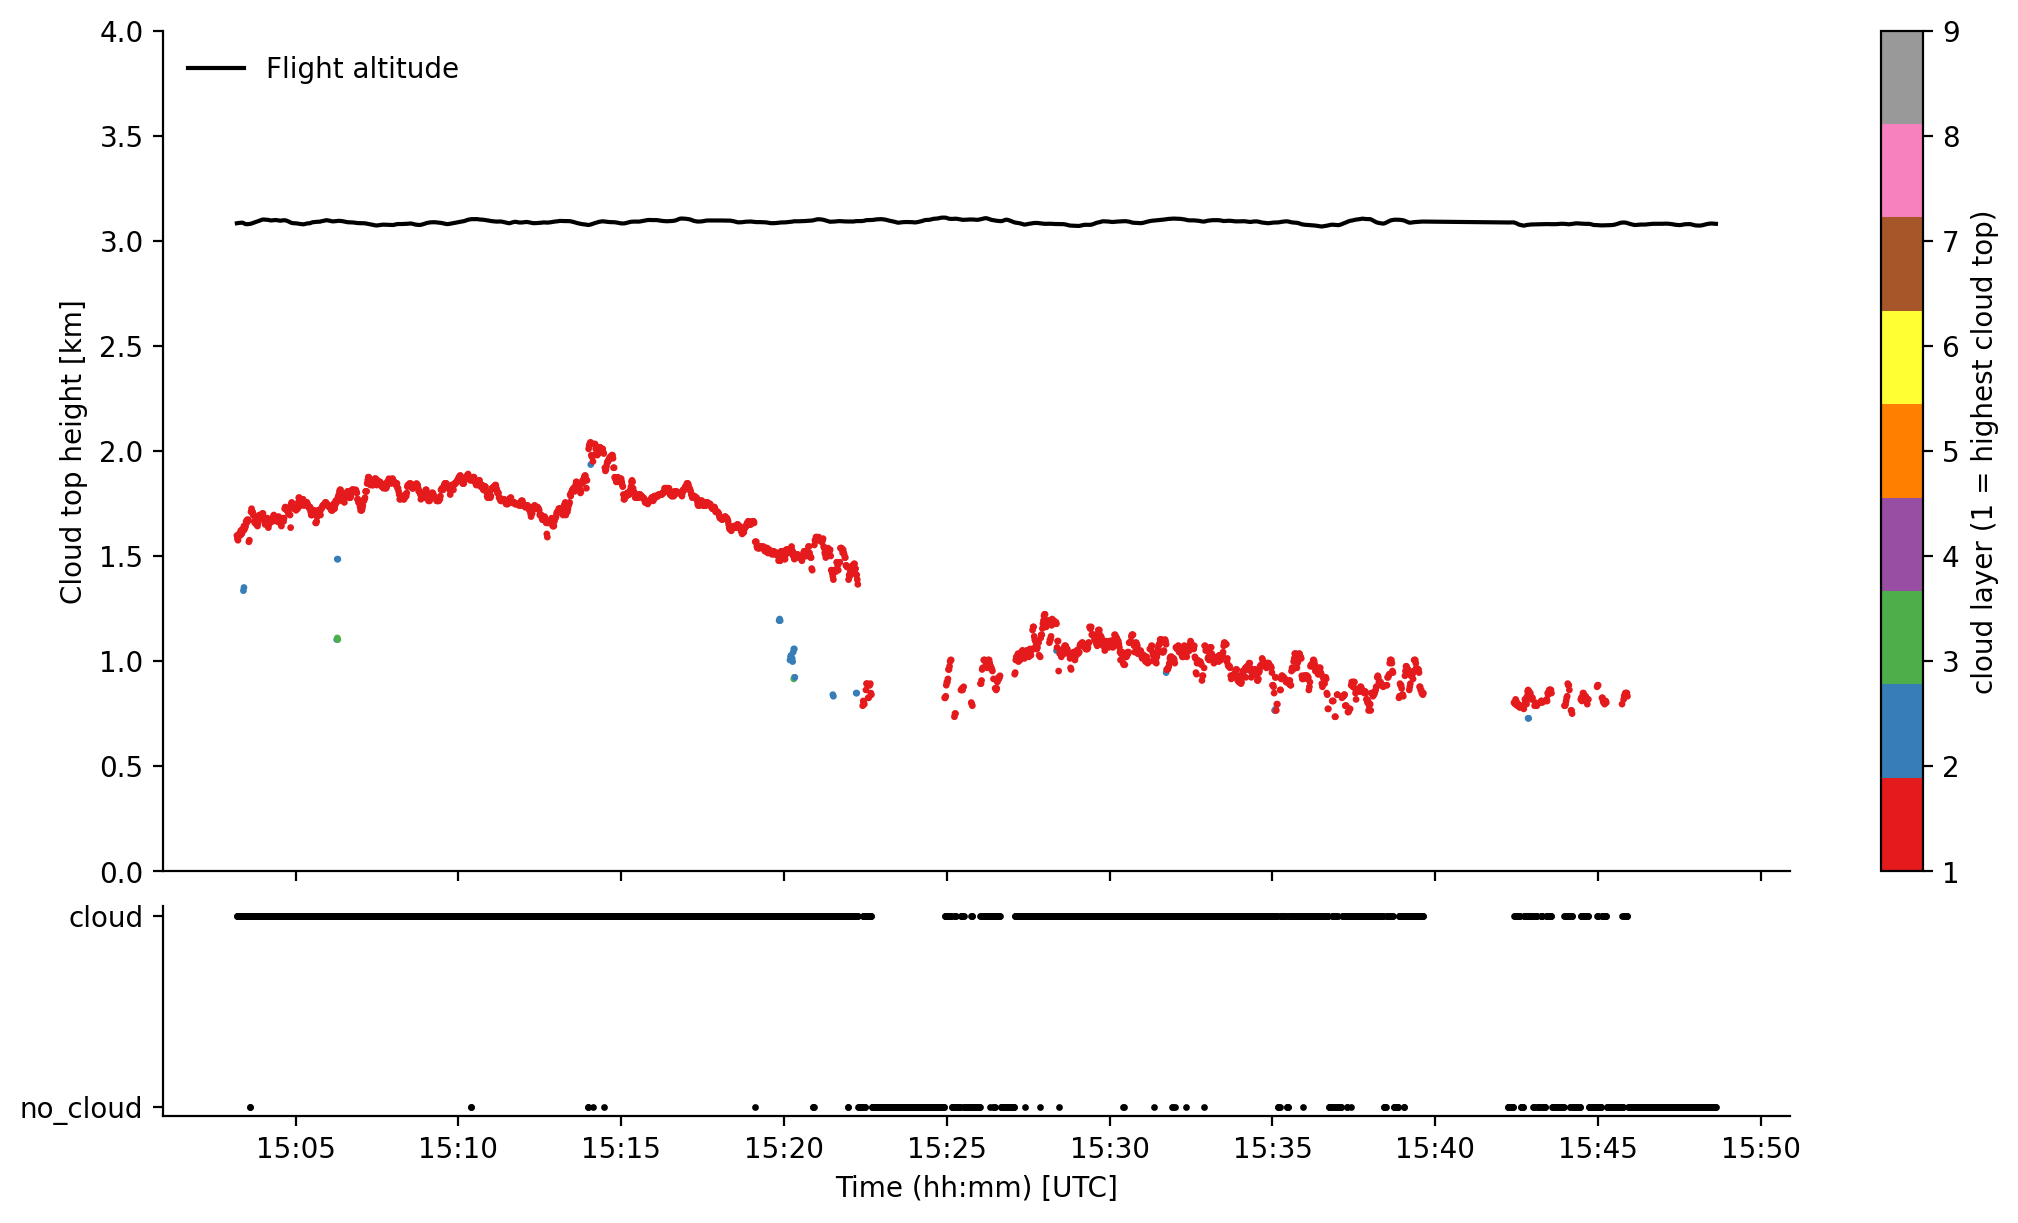

In [42]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw=dict(height_ratios=[1, 0.25]))

# 1st: plot flight altitude and cloud top height with seperate colors for each layer
ax1.plot(ds_cloud_top_height_sel.time, ds_cloud_top_height_sel.alt*1e-3, color='k', label='Flight altitude')

stack = ds_cloud_top_height_sel.cth.stack({'tl': ['time', 'cloud_layer']})
im = ax1.scatter(x=stack.time, y=stack*1e-3, c=stack.cloud_layer, s=2, vmin=1, vmax=9, cmap='Set1')
fig.colorbar(im, ax=ax1, label='cloud layer (1 = highest cloud top)')
ax1.set_ylim(0, 4)
ax1.set_ylabel('Cloud top height [km]')

ax1.legend(frameon=False, loc='upper left')

# 3rd: plot cloud mask in lower part of the figure
ax2.scatter(ds_cloud_mask_sel.time, ds_cloud_mask_sel.cloud_mask, s=2, color='k')
ax2.set_yticks([int(x) for x in ds_cloud_mask_sel.cloud_mask.attrs['flag_values']])
ax2.set_yticklabels([x for x in ds_cloud_mask_sel.cloud_mask.attrs['flag_meanings'].split(' ')])
ax2.set_xlabel('Time (hh:mm) [UTC]')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.show()